# 08 销量代理与发行策略辅助分析

本 Notebook 在前面市场结构、玩家反馈和标签定位分析的基础上，进一步使用 `estimated_owners` 字段构造一个**销量规模代理指标**，用于支持报告最后面向游戏发行方的简单建议。

需要特别说明：`estimated_owners` 不是 Steam 官方公布的真实销量，而是第三方数据中的估计拥有者区间。本 Notebook 为了进行课程项目中的描述性分析，暂时将该字段的区间中点作为“估计销量代理值”。因此，后续结论只能用于观察趋势和提出初步建议，不能作为商业决策中的精确销量预测。

## 1. 数据读取与分析设定

本节读取 Notebook 03 生成的特征数据。该数据已经完成基础清洗、日期转换、数值字段转换、多标签解析和基础特征工程，因此可以直接用于进一步分析。

本 Notebook 会重点使用以下字段：

- `estimated_owners`：估计拥有者区间，本节将其解析为销量代理；
- `price` 和 `is_free`：区分免费游戏与买断制游戏；
- `genres_list`、`tags_list`、`categories_list`：分析类型和标签定位；
- `review_count_calc`、`positive_rate_calc`、`recommendations`、`peak_ccu`：衡量讨论热度、玩家反馈和在线表现。

In [1]:
from pathlib import Path
import ast
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# 兼容从项目根目录、notebooks/ 目录或 VS Code/Jupyter 临时目录执行 Notebook 的情况。
current_dir = Path.cwd().resolve()
fallback_root = Path("/Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights")
root_candidates = [fallback_root, current_dir, *current_dir.parents]
PROJECT_ROOT = next(
    (
        candidate for candidate in root_candidates
        if (candidate / "README.md").exists() and (candidate / "data" / "processed").exists()
    ),
    current_dir,
)
print("Project root:", PROJECT_ROOT)
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "steam_march2025_features.parquet"
FIGURES_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 160

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "未找到 data/processed/steam_march2025_features.parquet。请先运行 Notebook 03 生成特征数据。"
    )

df = pd.read_parquet(DATA_PATH)
print(f"数据维度: {df.shape[0]:,} 行 x {df.shape[1]:,} 列")

display(df[["appid", "name", "price", "is_free", "estimated_owners", "review_count_calc", "positive_rate_calc", "recommendations", "peak_ccu"]].head())

Project root: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights


数据维度: 89,618 行 x 63 列


,appid,name,price,is_free,estimated_owners,review_count_calc,positive_rate_calc,recommendations,peak_ccu
0,730,Counter-Strike 2,0.00,True,100000000 - 200000000,8615921,86.825460,4401572,1212356
1,578080,PUBG: BATTLEGROUNDS,0.00,True,50000000 - 100000000,2512396,59.224740,1732007,616738
2,570,Dota 2,0.00,True,200000000 - 500000000,2449800,81.576537,14337,555977
3,271590,Grand Theft Auto V Legacy,0.00,True,50000000 - 100000000,1969962,87.308791,1803063,117698
4,359550,Tom Clancy's Rainbow Six® Siege,3.99,False,20000000 - 50000000,1371209,84.069095,1165929,89916


## 2. 解析 estimated_owners 字段

`estimated_owners` 通常以区间形式出现，例如 `20000 - 50000` 或 `1000000 - 2000000`。为了方便比较，本节将其拆分为下界、上界和区间中点。

在后续分析中：

- 对买断制游戏，区间中点近似看作“估计销量代理值”；
- 对免费游戏，区间中点更适合理解为“估计入库或拥有者规模”，不能等同于销售收入；
- 如果进一步计算收入代理，只对买断制游戏使用 `price * estimated_owner_mid`，并且只作为粗略参考。

In [2]:
def parse_owner_range(value):
    """将 estimated_owners 的区间字符串解析为 lower、upper、mid。"""
    if pd.isna(value):
        return pd.Series({"owner_lower": np.nan, "owner_upper": np.nan, "owner_mid": np.nan})
    text = str(value).replace(",", "").strip()
    numbers = [int(x) for x in re.findall(r"\d+", text)]
    if len(numbers) >= 2:
        lower, upper = numbers[0], numbers[1]
    elif len(numbers) == 1:
        lower = upper = numbers[0]
    else:
        lower = upper = np.nan
    mid = (lower + upper) / 2 if pd.notna(lower) and pd.notna(upper) else np.nan
    return pd.Series({"owner_lower": lower, "owner_upper": upper, "owner_mid": mid})

owner_parts = df["estimated_owners"].apply(parse_owner_range)
analysis_df = pd.concat([df.copy(), owner_parts], axis=1)
analysis_df["owner_mid_log1p"] = np.log1p(analysis_df["owner_mid"])
analysis_df["review_count_log1p"] = np.log1p(analysis_df["review_count_calc"].fillna(0))
analysis_df["recommendations_log1p"] = np.log1p(analysis_df["recommendations"].fillna(0))
analysis_df["peak_ccu_log1p"] = np.log1p(analysis_df["peak_ccu"].fillna(0))

# 买断制游戏的粗略收入代理：不考虑折扣、地区定价、退款、分成和税费。
analysis_df["gross_revenue_proxy_mid"] = np.where(
    (~analysis_df["is_free"].fillna(False)) & (analysis_df["price"].fillna(0) > 0),
    analysis_df["owner_mid"] * analysis_df["price"],
    np.nan,
)
analysis_df["gross_revenue_proxy_log1p"] = np.log1p(analysis_df["gross_revenue_proxy_mid"])

owner_bucket_summary = (
    analysis_df.groupby("estimated_owners", dropna=False)
    .agg(
        game_count=("appid", "count"),
        owner_lower=("owner_lower", "min"),
        owner_upper=("owner_upper", "max"),
        owner_mid=("owner_mid", "median"),
        median_review_count=("review_count_calc", "median"),
        median_recommendations=("recommendations", "median"),
        median_peak_ccu=("peak_ccu", "median"),
    )
    .reset_index()
    .sort_values("owner_lower")
)

owner_bucket_summary.to_csv(PROCESSED_DIR / "steam_sales_proxy_owner_bucket_summary.csv", index=False)
display(owner_bucket_summary.head(12))
print("estimated_owners 缺失数量:", analysis_df["owner_mid"].isna().sum())

,estimated_owners,game_count,owner_lower,owner_upper,owner_mid,median_review_count,median_recommendations,median_peak_ccu
0,0 - 0,8418,0.0,0.0,0.0,0.0,0.0,0.0
1,0 - 20000,59320,0.0,20000.0,10000.0,10.0,0.0,0.0
6,20000 - 50000,9683,20000.0,50000.0,35000.0,89.0,0.0,0.0
11,50000 - 100000,4552,50000.0,100000.0,75000.0,288.0,149.0,0.0
2,100000 - 200000,3005,100000.0,200000.0,150000.0,803.0,479.0,2.0
7,200000 - 500000,2469,200000.0,500000.0,350000.0,2336.0,1544.0,8.0
12,500000 - 1000000,1038,500000.0,1000000.0,750000.0,7620.0,5348.5,45.0
3,1000000 - 2000000,574,1000000.0,2000000.0,1500000.0,18712.0,13604.5,176.5
8,2000000 - 5000000,373,2000000.0,5000000.0,3500000.0,54381.0,38074.0,604.0
13,5000000 - 10000000,108,5000000.0,10000000.0,7500000.0,123943.5,90788.5,2279.5


estimated_owners 缺失数量: 0


下面的图展示不同估计拥有者区间中的游戏数量。由于 Steam 游戏市场本身具有明显长尾结构，大量游戏集中在较低拥有者区间，少数游戏进入较高拥有者区间。

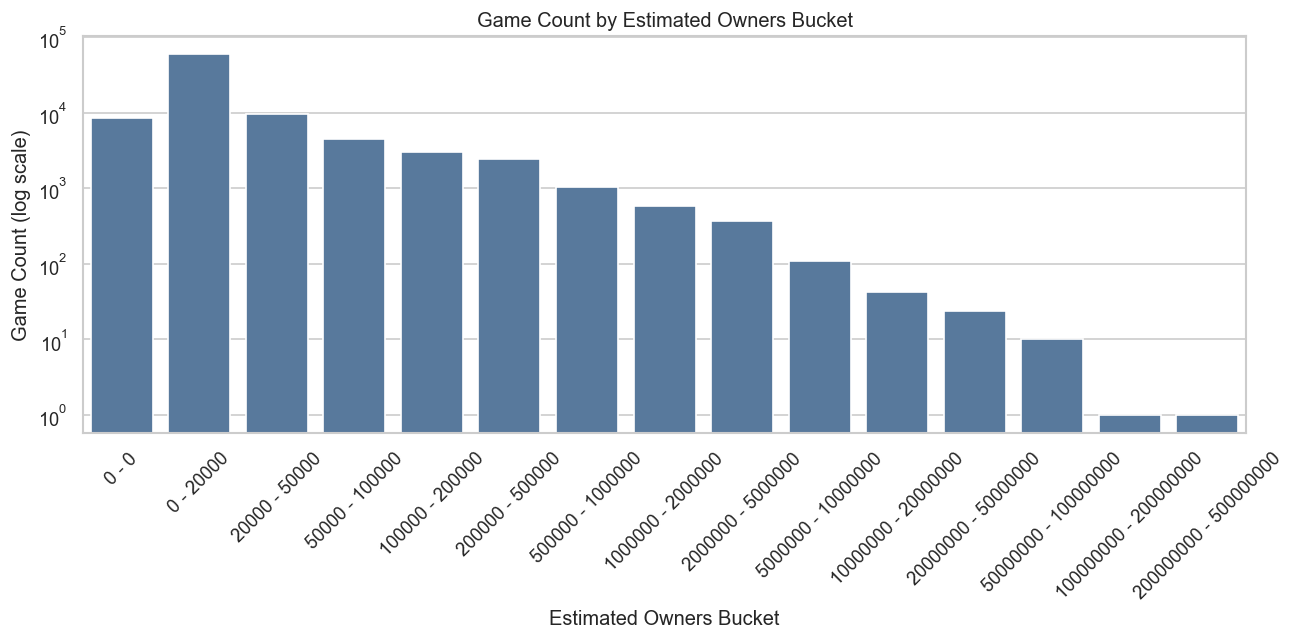

保存图表: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/39_estimated_owners_bucket_distribution.png


In [3]:
plot_owner = owner_bucket_summary.dropna(subset=["owner_mid"]).copy()
plot_owner["owner_label"] = plot_owner["estimated_owners"].astype(str)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=plot_owner, x="owner_label", y="game_count", ax=ax, color="#4C78A8")
ax.set_yscale("log")
ax.set_title("Game Count by Estimated Owners Bucket")
ax.set_xlabel("Estimated Owners Bucket")
ax.set_ylabel("Game Count (log scale)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig_path = FIGURES_DIR / "39_estimated_owners_bucket_distribution.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print("保存图表:", fig_path)

## 3. 销量代理与讨论热度的关系

对于买断制游戏来说，估计拥有者数量可以粗略反映“卖出去的规模”；而评论数、推荐数和在线人数更接近玩家讨论与持续参与。二者相关，但并不完全相同。

这一点对后续建议很重要：

- 独立开发者可能更关注买断制游戏的基础销售规模；
- 大型发行商可能同时关注讨论热度、传播度和在线表现；
- 免费在线运营游戏不能用销量衡量，更需要看评论、好评率、峰值在线人数等指标。

,owner_mid_log1p,review_count_log1p,recommendations_log1p,peak_ccu_log1p,positive_rate_calc,price
owner_mid_log1p,1.000,0.608,0.363,0.344,0.055,0.169
review_count_log1p,0.608,1.000,0.731,0.629,0.128,0.201
recommendations_log1p,0.363,0.731,1.000,0.688,0.126,0.235
peak_ccu_log1p,0.344,0.629,0.688,1.000,0.124,0.242
positive_rate_calc,0.055,0.128,0.126,0.124,1.000,0.004
price,0.169,0.201,0.235,0.242,0.004,1.000


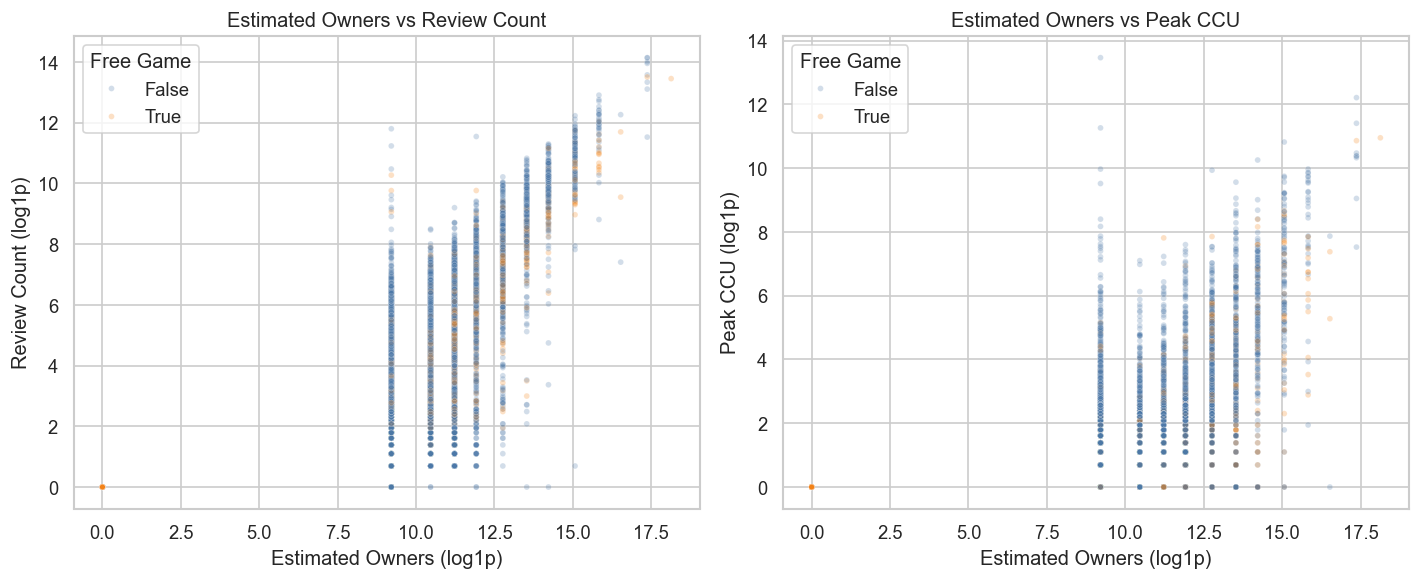

保存图表: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/40_sales_proxy_vs_discussion_metrics.png


In [4]:
relationship_cols = [
    "owner_mid_log1p",
    "review_count_log1p",
    "recommendations_log1p",
    "peak_ccu_log1p",
    "positive_rate_calc",
    "price",
]
relationship_corr = analysis_df[relationship_cols].corr().round(3)
display(relationship_corr)

sample_scatter = analysis_df.dropna(subset=["owner_mid", "review_count_calc"]).copy()
if len(sample_scatter) > 30000:
    sample_scatter = sample_scatter.sample(30000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(
    data=sample_scatter,
    x="owner_mid_log1p",
    y="review_count_log1p",
    hue="is_free",
    alpha=0.25,
    s=12,
    ax=axes[0],
    palette={False: "#4C78A8", True: "#F58518"},
)
axes[0].set_title("Estimated Owners vs Review Count")
axes[0].set_xlabel("Estimated Owners (log1p)")
axes[0].set_ylabel("Review Count (log1p)")
axes[0].legend(title="Free Game")

sns.scatterplot(
    data=sample_scatter,
    x="owner_mid_log1p",
    y="peak_ccu_log1p",
    hue="is_free",
    alpha=0.25,
    s=12,
    ax=axes[1],
    palette={False: "#4C78A8", True: "#F58518"},
)
axes[1].set_title("Estimated Owners vs Peak CCU")
axes[1].set_xlabel("Estimated Owners (log1p)")
axes[1].set_ylabel("Peak CCU (log1p)")
axes[1].legend(title="Free Game")

plt.tight_layout()
fig_path = FIGURES_DIR / "40_sales_proxy_vs_discussion_metrics.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print("保存图表:", fig_path)

## 4. 买断制游戏：定价与销量代理

本节只分析买断制游戏。对于这类游戏，`estimated_owners` 更接近“卖出规模”的代理指标，价格和估计拥有者数量还可以进一步构造非常粗略的收入代理。

需要注意：收入代理不考虑折扣、地区定价、退款、Steam 分成、税费、捆绑包和 DLC，因此只能用于比较不同价格区间的大致趋势。

,price_bucket,game_count,median_price,median_owner_mid,mean_owner_mid,median_review_count,median_positive_rate,median_gross_revenue_proxy
0,$0.01-4.99,39388,2.99,10000.0,3.687989e+04,9.0,80.851064,29900.0
1,$5-9.99,19090,8.99,10000.0,5.810922e+04,16.0,83.333333,99900.0
2,$10-19.99,12731,14.99,10000.0,1.445248e+05,57.0,82.975430,189900.0
3,$20-39.99,3356,29.99,10000.0,4.009565e+05,263.5,80.992866,399900.0
4,$40-79.99,673,59.99,35000.0,1.047734e+06,791.0,79.418127,2099650.0
5,$80+,220,199.99,10000.0,1.297727e+04,3.5,63.060429,1999900.0


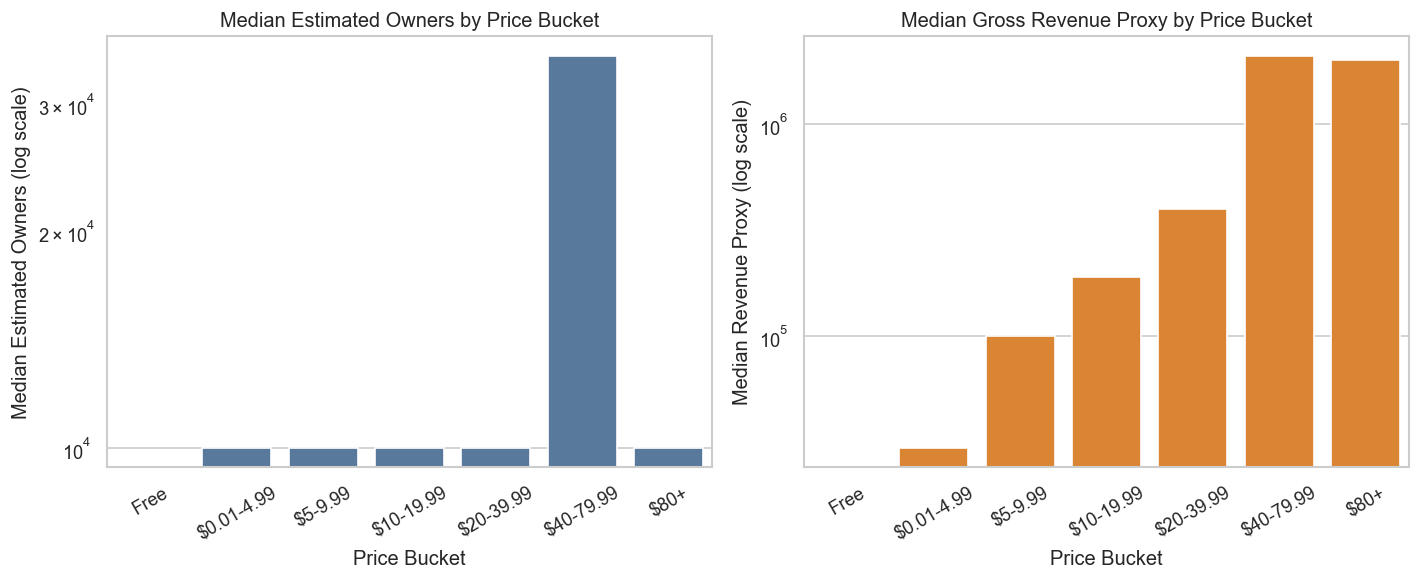

保存图表: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/41_buyout_price_bucket_sales_proxy.png


In [5]:
price_bins = [-0.01, 0, 4.99, 9.99, 19.99, 39.99, 79.99, np.inf]
price_labels = ["Free", "$0.01-4.99", "$5-9.99", "$10-19.99", "$20-39.99", "$40-79.99", "$80+"]
analysis_df["price_bucket"] = pd.cut(analysis_df["price"].fillna(0), bins=price_bins, labels=price_labels)

buyout_df = analysis_df[(~analysis_df["is_free"].fillna(False)) & (analysis_df["price"].fillna(0) > 0)].copy()

price_summary = (
    buyout_df.groupby("price_bucket", observed=True)
    .agg(
        game_count=("appid", "count"),
        median_price=("price", "median"),
        median_owner_mid=("owner_mid", "median"),
        mean_owner_mid=("owner_mid", "mean"),
        median_review_count=("review_count_calc", "median"),
        median_positive_rate=("positive_rate_calc", "median"),
        median_gross_revenue_proxy=("gross_revenue_proxy_mid", "median"),
    )
    .reset_index()
)
price_summary.to_csv(PROCESSED_DIR / "steam_sales_proxy_price_bucket_summary.csv", index=False)
display(price_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=price_summary, x="price_bucket", y="median_owner_mid", ax=axes[0], color="#4C78A8")
axes[0].set_yscale("log")
axes[0].set_title("Median Estimated Owners by Price Bucket")
axes[0].set_xlabel("Price Bucket")
axes[0].set_ylabel("Median Estimated Owners (log scale)")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=price_summary, x="price_bucket", y="median_gross_revenue_proxy", ax=axes[1], color="#F58518")
axes[1].set_yscale("log")
axes[1].set_title("Median Gross Revenue Proxy by Price Bucket")
axes[1].set_xlabel("Price Bucket")
axes[1].set_ylabel("Median Revenue Proxy (log scale)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
fig_path = FIGURES_DIR / "41_buyout_price_bucket_sales_proxy.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print("保存图表:", fig_path)

## 5. 独立开发者视角：类型与标签选择

对于独立开发者，资源通常有限，因此需要同时考虑两个问题：

1. 哪些类型或标签的买断制游戏更容易达到较高估计拥有者规模；
2. 哪些标签不是极端拥挤的红海，但仍然有相对不错的销量代理和玩家反馈。

本节先基于 `genres_list` 和 `tags_list` 拆分多标签字段，然后分别统计类型和标签层面的估计拥有者中位数、评论数中位数和好评率。

In [6]:
def normalize_multilabel_value(value):
    """兼容 pipe 字符串、Python list 字符串、dict 字符串和普通字符串。"""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, (list, tuple, set)):
        return [str(x).strip() for x in value if str(x).strip()]
    text = str(value).strip()
    if not text or text.lower() == "nan":
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, dict):
            return [str(k).strip() for k in parsed.keys() if str(k).strip()]
        if isinstance(parsed, (list, tuple, set)):
            return [str(x).strip() for x in parsed if str(x).strip()]
    except Exception:
        pass
    if "|" in text:
        parts = text.split("|")
    elif ";" in text:
        parts = text.split(";")
    else:
        parts = [text]
    return [p.strip() for p in parts if p.strip()]


def explode_multilabel(df, column, label_name):
    if column not in df.columns:
        return pd.DataFrame(columns=["appid", label_name])
    temp = df[["appid", column]].copy()
    temp[label_name] = temp[column].apply(normalize_multilabel_value)
    temp = temp.explode(label_name).dropna(subset=[label_name])
    temp[label_name] = temp[label_name].astype(str).str.strip()
    temp = temp[temp[label_name] != ""]
    return temp[["appid", label_name]]

genre_long = explode_multilabel(analysis_df, "genres_list", "genre")
tag_long = explode_multilabel(analysis_df, "tags_list", "tag")
category_long = explode_multilabel(analysis_df, "categories_list", "category")

print(f"genre 长表行数: {len(genre_long):,}")
print(f"tag 长表行数: {len(tag_long):,}")
print(f"category 长表行数: {len(category_long):,}")

genre 长表行数: 258,024
tag 长表行数: 1,008,987
category 长表行数: 376,153


,genre,game_count,median_owner_mid,median_price,median_review_count,median_positive_rate_30plus,median_revenue_proxy
2,Action,31199,10000.0,4.99,16.0,80.303030,69900.0
16,Massively Multiplayer,965,10000.0,6.99,23.0,69.767442,99900.0
29,Utilities,595,10000.0,7.99,15.0,75.328084,99900.0
27,Strategy,14709,10000.0,5.99,19.0,79.484810,89900.0
26,Sports,3387,10000.0,6.99,16.0,78.407557,79900.0
24,Simulation,16037,10000.0,6.99,21.0,78.666667,79900.0
21,Racing,2862,10000.0,4.99,14.0,78.028289,59900.0
20,RPG,13785,10000.0,6.99,21.0,80.728220,99900.0
15,Indie,54122,10000.0,4.99,16.0,81.818182,59900.0
3,Adventure,30631,10000.0,5.99,19.0,81.753630,79900.0


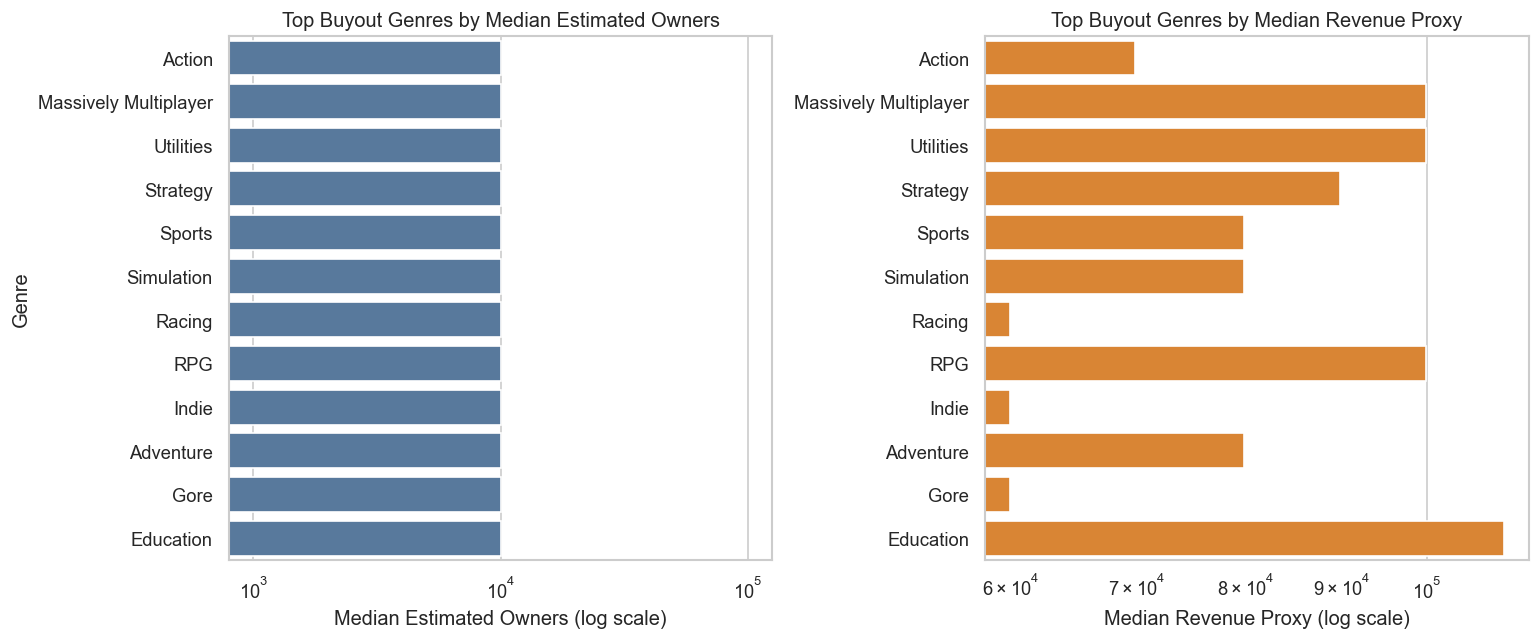

保存图表: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/42_buyout_genre_sales_proxy.png


In [7]:
base_metrics = analysis_df[[
    "appid", "name", "is_free", "price", "owner_mid", "owner_mid_log1p", "gross_revenue_proxy_mid",
    "review_count_calc", "positive_rate_calc", "recommendations", "peak_ccu", "release_year"
]].copy()
base_metrics["has_reliable_review_rate"] = base_metrics["review_count_calc"].fillna(0) >= 30

buyout_metrics = base_metrics[(~base_metrics["is_free"].fillna(False)) & (base_metrics["price"].fillna(0) > 0)].copy()

buyout_genre = genre_long.merge(buyout_metrics, on="appid", how="inner")
genre_sales_summary = (
    buyout_genre.groupby("genre")
    .agg(
        game_count=("appid", "count"),
        median_owner_mid=("owner_mid", "median"),
        median_price=("price", "median"),
        median_review_count=("review_count_calc", "median"),
        median_positive_rate_30plus=("positive_rate_calc", lambda s: s[buyout_genre.loc[s.index, "has_reliable_review_rate"]].median()),
        median_revenue_proxy=("gross_revenue_proxy_mid", "median"),
    )
    .reset_index()
)
genre_sales_summary = genre_sales_summary[genre_sales_summary["game_count"] >= 200].sort_values("median_owner_mid", ascending=False)
genre_sales_summary.to_csv(PROCESSED_DIR / "steam_sales_proxy_genre_summary.csv", index=False)
display(genre_sales_summary.head(15))

plot_genre = genre_sales_summary.head(12).copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.barplot(data=plot_genre, y="genre", x="median_owner_mid", ax=axes[0], color="#4C78A8")
axes[0].set_xscale("log")
axes[0].set_title("Top Buyout Genres by Median Estimated Owners")
axes[0].set_xlabel("Median Estimated Owners (log scale)")
axes[0].set_ylabel("Genre")

sns.barplot(data=plot_genre, y="genre", x="median_revenue_proxy", ax=axes[1], color="#F58518")
axes[1].set_xscale("log")
axes[1].set_title("Top Buyout Genres by Median Revenue Proxy")
axes[1].set_xlabel("Median Revenue Proxy (log scale)")
axes[1].set_ylabel("")

plt.tight_layout()
fig_path = FIGURES_DIR / "42_buyout_genre_sales_proxy.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print("保存图表:", fig_path)

,tag,game_count,median_owner_mid,median_price,median_review_count,median_positive_rate_30plus,median_revenue_proxy
209,Kickstarter,136,75000.0,14.990,878.0,82.433524,955500.0
401,Touch-Friendly,171,35000.0,4.990,198.0,88.165266,139650.0
339,Sequel,111,35000.0,5.990,130.0,86.486486,149900.0
245,Moddable,471,35000.0,12.990,247.0,86.335156,349650.0
139,Episodic,90,35000.0,5.990,112.5,85.975610,129900.0
428,Villain Protagonist,145,35000.0,8.990,328.0,85.110892,199900.0
222,Lovecraftian,536,35000.0,6.990,53.5,84.346218,149900.0
93,Conspiracy,358,35000.0,4.995,18.0,83.484848,129900.0
84,Cold War,130,35000.0,5.490,46.0,82.971770,139650.0
372,Steampunk,316,35000.0,9.990,73.0,82.554517,199900.0


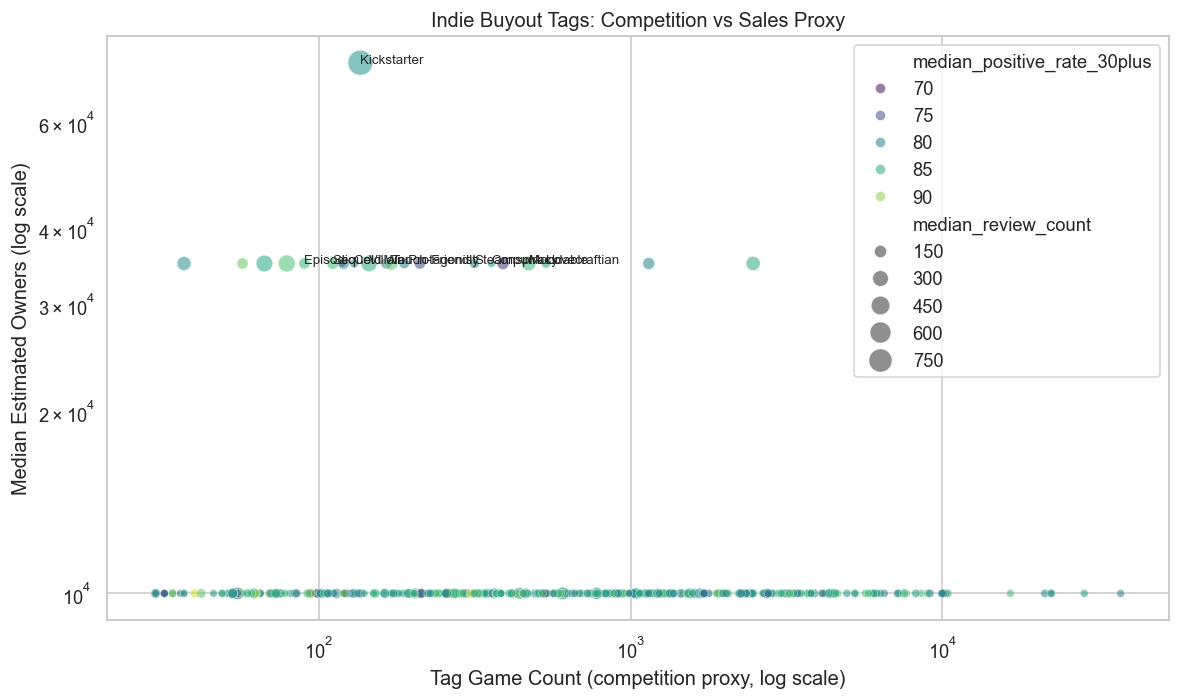

保存图表: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/43_indie_tag_sales_proxy_candidates.png


In [8]:
buyout_tags = tag_long.merge(buyout_metrics, on="appid", how="inner")
indie_appids = set(genre_long.loc[genre_long["genre"].str.lower() == "indie", "appid"])
buyout_tags["is_indie_positioned"] = buyout_tags["appid"].isin(indie_appids)

indie_buyout_tags = buyout_tags[buyout_tags["is_indie_positioned"]].copy()

tag_strategy_summary = (
    indie_buyout_tags.groupby("tag")
    .agg(
        game_count=("appid", "count"),
        median_owner_mid=("owner_mid", "median"),
        median_price=("price", "median"),
        median_review_count=("review_count_calc", "median"),
        median_positive_rate_30plus=("positive_rate_calc", lambda s: s[indie_buyout_tags.loc[s.index, "has_reliable_review_rate"]].median()),
        median_revenue_proxy=("gross_revenue_proxy_mid", "median"),
    )
    .reset_index()
)

# 简单寻找“不是特别拥挤，但销量代理和反馈都还不错”的候选标签。
min_games = 80
max_games = tag_strategy_summary["game_count"].quantile(0.70)
owner_threshold = tag_strategy_summary.loc[tag_strategy_summary["game_count"] >= min_games, "median_owner_mid"].quantile(0.70)
rate_threshold = 75

indie_tag_candidates = tag_strategy_summary[
    (tag_strategy_summary["game_count"] >= min_games)
    & (tag_strategy_summary["game_count"] <= max_games)
    & (tag_strategy_summary["median_owner_mid"] >= owner_threshold)
    & (tag_strategy_summary["median_positive_rate_30plus"].fillna(0) >= rate_threshold)
].sort_values(["median_owner_mid", "median_positive_rate_30plus"], ascending=False)

indie_tag_candidates.to_csv(PROCESSED_DIR / "steam_sales_proxy_indie_tag_candidates.csv", index=False)
display(indie_tag_candidates.head(20))

plot_tags = indie_tag_candidates.head(15).copy()
if len(plot_tags) == 0:
    plot_tags = tag_strategy_summary[tag_strategy_summary["game_count"] >= min_games].sort_values("median_owner_mid", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=tag_strategy_summary[tag_strategy_summary["game_count"] >= 30],
    x="game_count",
    y="median_owner_mid",
    size="median_review_count",
    hue="median_positive_rate_30plus",
    sizes=(20, 220),
    alpha=0.55,
    palette="viridis",
    ax=ax,
)
for _, row in plot_tags.head(10).iterrows():
    ax.text(row["game_count"], row["median_owner_mid"], row["tag"], fontsize=8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Indie Buyout Tags: Competition vs Sales Proxy")
ax.set_xlabel("Tag Game Count (competition proxy, log scale)")
ax.set_ylabel("Median Estimated Owners (log scale)")
plt.tight_layout()
fig_path = FIGURES_DIR / "43_indie_tag_sales_proxy_candidates.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print("保存图表:", fig_path)

## 6. 大型发行商视角：哪些游戏更容易形成讨论热度

对于投入较高的大型发行商来说，销量当然重要，但“讨论热度”也很重要。评论数、推荐数和峰值在线人数能够反映游戏是否进入更广泛的玩家讨论和持续参与。

本节构造一个简单的描述性讨论热度分数：对评论数、推荐数和峰值在线人数取 `log1p` 后标准化，再求平均。这个分数不是机器学习模型，只是为了把多个热度指标放在同一尺度上比较。

,appid,name,price,is_free,estimated_owners,owner_mid,review_count_calc,recommendations,peak_ccu,positive_rate_calc,discussion_score
0,730,Counter-Strike 2,0.00,True,100000000 - 200000000,150000000.0,8615921,4401572,1212356,86.825460,7.345754
1,578080,PUBG: BATTLEGROUNDS,0.00,True,50000000 - 100000000,75000000.0,2512396,1732007,616738,59.224740,6.869804
7,252490,Rust,39.99,False,20000000 - 50000000,35000000.0,1195980,992825,200902,87.268015,6.386431
3,271590,Grand Theft Auto V Legacy,0.00,True,50000000 - 100000000,75000000.0,1969962,1803063,117698,87.308791,6.383941
2,570,Dota 2,0.00,True,200000000 - 500000000,350000000.0,2449800,14337,555977,81.576537,6.222997
4,359550,Tom Clancy's Rainbow Six® Siege,3.99,False,20000000 - 50000000,35000000.0,1371209,1165929,89916,84.069095,6.203786
56729,431960,Wallpaper Engine,4.99,False,20000000 - 50000000,35000000.0,872956,809225,120461,98.036556,6.175579
182,2246340,Monster Hunter Wilds,69.99,False,0 - 20000,10000.0,132740,88048,703236,56.253578,6.119246
13,413150,Stardew Valley,14.99,False,20000000 - 50000000,35000000.0,854853,729406,67309,98.427800,5.998602
12,1245620,ELDEN RING,59.99,False,20000000 - 50000000,35000000.0,1029858,749109,46121,92.842314,5.923239


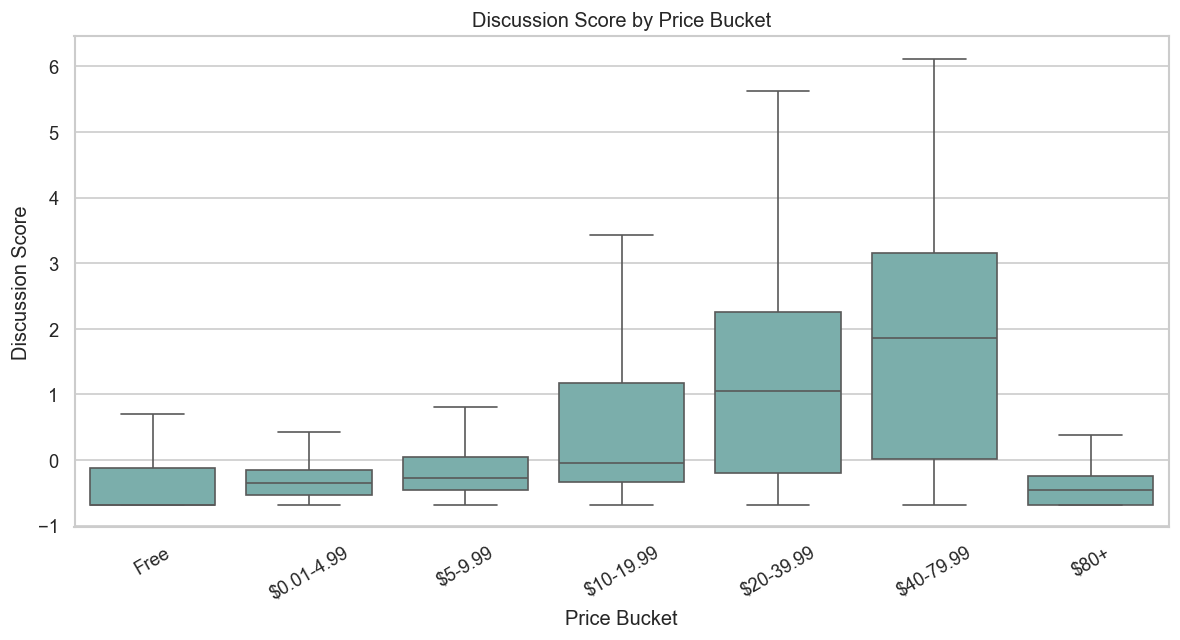

保存图表: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/44_discussion_score_by_price_bucket.png


In [9]:
def zscore(series):
    series = pd.to_numeric(series, errors="coerce")
    std = series.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.mean()) / std

analysis_df["discussion_score"] = (
    zscore(analysis_df["review_count_log1p"]) +
    zscore(analysis_df["recommendations_log1p"]) +
    zscore(analysis_df["peak_ccu_log1p"])
) / 3

publisher_focus = analysis_df.copy()
publisher_focus["discussion_score_quantile"] = pd.qcut(
    publisher_focus["discussion_score"].rank(method="first"),
    q=5,
    labels=["Bottom 20%", "20-40%", "40-60%", "60-80%", "Top 20%"],
)

discussion_by_price = (
    publisher_focus.groupby(["price_bucket", "discussion_score_quantile"], observed=True)
    .size()
    .reset_index(name="game_count")
)

discussion_top_games = publisher_focus.sort_values("discussion_score", ascending=False)[[
    "appid", "name", "price", "is_free", "estimated_owners", "owner_mid", "review_count_calc", "recommendations", "peak_ccu", "positive_rate_calc", "discussion_score"
]].head(20)

display(discussion_top_games)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(data=publisher_focus, x="price_bucket", y="discussion_score", ax=ax, color="#72B7B2", showfliers=False)
ax.set_title("Discussion Score by Price Bucket")
ax.set_xlabel("Price Bucket")
ax.set_ylabel("Discussion Score")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
fig_path = FIGURES_DIR / "44_discussion_score_by_price_bucket.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print("保存图表:", fig_path)

## 7. 免费在线运营游戏视角：销量代理不是核心指标

如果目标是发布免费在线运营游戏，那么 `estimated_owners` 更像入库或触达规模，而不是收入。此时更值得关注的是：

- 是否有足够评论数，说明玩家愿意反馈和讨论；
- 好评率是否稳定，说明基础口碑是否健康；
- 峰值在线人数是否较高，说明是否有持续在线参与；
- 推荐数是否较高，说明是否具备传播基础。

因此，本节只在免费游戏内部比较标签，而不把 `estimated_owners` 解释为销量。

需要注意的是，成人向或成熟内容标签也是 Steam 生态中的真实细分市场。若这类标签在数据中排名较高，不应该简单回避；它可能说明部分小型发行方会利用明确的受众偏好和较低制作门槛来获取关注或销量。但这也可能带来低质量作品集中、标签泛滥和市场噪声增加的问题。因此，在报告中更适合把它作为一个特殊细分市场现象进行讨论，而不是作为通用的发行建议。

,tag,game_count,median_owner_mid,median_review_count,median_positive_rate_30plus,median_recommendations,median_peak_ccu,free_operation_score
192,Idler,124,150000.0,438.5,78.717548,0.0,11.5,3.027084
243,Moddable,54,250000.0,753.0,80.000000,0.0,5.0,2.588657
183,Hentai,58,150000.0,1189.0,83.975535,0.0,2.0,2.321347
222,MMORPG,229,350000.0,745.0,67.466803,0.0,8.0,2.226168
231,Mature,79,150000.0,1071.0,81.594646,0.0,2.0,2.136443
270,Online Co-Op,370,150000.0,906.5,73.437500,0.0,2.5,1.729837
402,Trading,42,75000.0,318.5,72.536394,0.0,4.5,1.716245
80,Co-op,559,350000.0,1029.0,73.911278,0.0,2.0,1.655304
79,Clicker,165,75000.0,326.0,75.994822,0.0,3.0,1.619788
78,Classic,68,75000.0,303.5,81.188119,0.0,1.0,1.221003


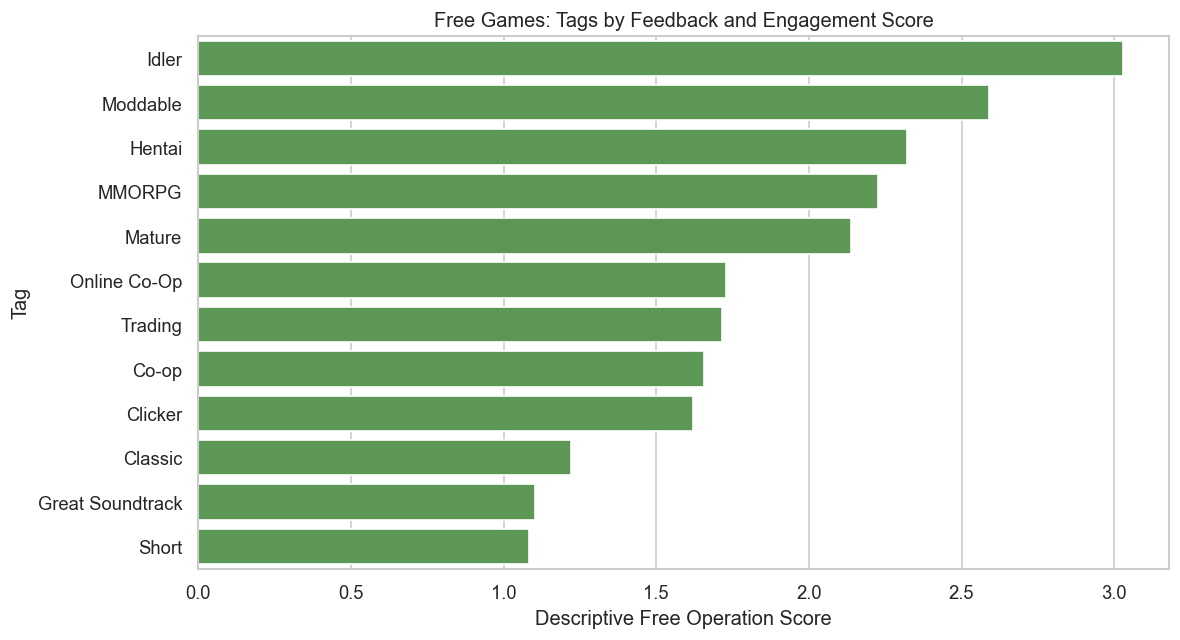

保存图表: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/45_free_game_tag_feedback_engagement.png


In [10]:
free_metrics = base_metrics[base_metrics["is_free"].fillna(False)].copy()
free_tags = tag_long.merge(free_metrics, on="appid", how="inner")

free_tag_summary = (
    free_tags.groupby("tag")
    .agg(
        game_count=("appid", "count"),
        median_owner_mid=("owner_mid", "median"),
        median_review_count=("review_count_calc", "median"),
        median_positive_rate_30plus=("positive_rate_calc", lambda s: s[free_tags.loc[s.index, "has_reliable_review_rate"]].median()),
        median_recommendations=("recommendations", "median"),
        median_peak_ccu=("peak_ccu", "median"),
    )
    .reset_index()
)
free_tag_summary = free_tag_summary[free_tag_summary["game_count"] >= 40].copy()
free_tag_summary["free_operation_score"] = (
    zscore(np.log1p(free_tag_summary["median_review_count"].fillna(0))) +
    zscore(free_tag_summary["median_positive_rate_30plus"].fillna(free_tag_summary["median_positive_rate_30plus"].median())) +
    zscore(np.log1p(free_tag_summary["median_peak_ccu"].fillna(0)))
) / 3
free_tag_summary = free_tag_summary.sort_values("free_operation_score", ascending=False)
free_tag_summary.to_csv(PROCESSED_DIR / "steam_sales_proxy_free_game_tag_summary.csv", index=False)

display(free_tag_summary.head(20))

plot_free_tags = free_tag_summary.head(12).copy()
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(data=plot_free_tags, y="tag", x="free_operation_score", ax=ax, color="#54A24B")
ax.set_title("Free Games: Tags by Feedback and Engagement Score")
ax.set_xlabel("Descriptive Free Operation Score")
ax.set_ylabel("Tag")
plt.tight_layout()
fig_path = FIGURES_DIR / "45_free_game_tag_feedback_engagement.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print("保存图表:", fig_path)

## 8. 面向不同发行目标的初步建议

本节把前面的统计结果整理成三个发行目标。这里不是给出确定性的商业结论，而是把数据分析结果转化成报告中可以讨论的“策略启发”。

由于本项目没有真实成本、营销预算、愿望单、转化率、退款率和真实收入数据，下面的建议只能作为基于当前数据的初步观察。

In [11]:
# 自动提取若干可写入报告的候选结果。
best_price_by_owner = price_summary.sort_values("median_owner_mid", ascending=False).head(1).iloc[0]
best_price_by_revenue = price_summary.sort_values("median_gross_revenue_proxy", ascending=False).head(1).iloc[0]
top_genres_for_buyout = genre_sales_summary.head(5)["genre"].tolist()
top_indie_tags = indie_tag_candidates.head(8)["tag"].tolist() if len(indie_tag_candidates) else plot_tags.head(8)["tag"].tolist()
top_free_tags = free_tag_summary.head(8)["tag"].tolist()

strategy_rows = [
    {
        "scenario": "独立开发者 / 买断制游戏",
        "main_goal": "在有限预算下获得较稳定的估计销量和基础收入",
        "suggested_metrics": "estimated_owners 区间中点、价格区间、粗略收入代理、好评率",
        "data_based_hint": f"从价格桶看，估计拥有者中位数较高的价格区间为 {best_price_by_owner['price_bucket']}；粗略收入代理中位数较高的价格区间为 {best_price_by_revenue['price_bucket']}。可重点参考的买断制类型包括：{', '.join(top_genres_for_buyout)}。",
        "caution": "estimated_owners 是估计区间，不是官方销量；低价可能提升拥有者规模，但不一定提升收入。",
    },
    {
        "scenario": "大型发行商 / 高投入游戏",
        "main_goal": "形成更高讨论热度、推荐数和在线参与",
        "suggested_metrics": "评论数、推荐数、peak_ccu、discussion_score、好评率",
        "data_based_hint": "应同时观察销量代理和讨论热度代理。高估计拥有者不一定等于高好评率，高评论数也可能伴随争议。",
        "caution": "讨论热度反映关注度，不直接等于口碑或利润。",
    },
    {
        "scenario": "免费在线运营游戏",
        "main_goal": "获得玩家反馈、在线参与和持续传播",
        "suggested_metrics": "评论数、好评率、推荐数、peak_ccu，而不是销售收入",
        "data_based_hint": f"免费游戏内部可关注反馈和在线表现较强的标签方向，例如：{', '.join(top_free_tags)}。",
        "caution": "免费游戏的 estimated_owners 更像触达或入库规模，不能解释为销量收入。",
    },
]

strategy_summary = pd.DataFrame(strategy_rows)
strategy_summary.to_csv(PROCESSED_DIR / "steam_sales_proxy_publishing_strategy_summary.csv", index=False)
display(strategy_summary)

,scenario,main_goal,suggested_metrics,data_based_hint,caution
0,独立开发者 / 买断制游戏,在有限预算下获得较稳定的估计销量和基础收入,estimated_owners 区间中点、价格区间、粗略收入代理、好评率,从价格桶看，估计拥有者中位数较高的价格区间为 $40-79.99；粗略收入代理中位数较高的价...,estimated_owners 是估计区间，不是官方销量；低价可能提升拥有者规模，但不一定...
1,大型发行商 / 高投入游戏,形成更高讨论热度、推荐数和在线参与,评论数、推荐数、peak_ccu、discussion_score、好评率,应同时观察销量代理和讨论热度代理。高估计拥有者不一定等于高好评率，高评论数也可能伴随争议。,讨论热度反映关注度，不直接等于口碑或利润。
2,免费在线运营游戏,获得玩家反馈、在线参与和持续传播,评论数、好评率、推荐数、peak_ccu，而不是销售收入,"免费游戏内部可关注反馈和在线表现较强的标签方向，例如：Idler, Moddable, He...",免费游戏的 estimated_owners 更像触达或入库规模，不能解释为销量收入。


## 9. 小结

本 Notebook 在不引入复杂模型的前提下，将 `estimated_owners` 作为估计销量代理，用于补充前面 Notebook 对市场结构、评论反馈和标签定位的分析。可以得到以下初步认识：

1. `estimated_owners` 可以为买断制游戏提供一个近似的销量规模参考，但不能等同于官方销量；
2. 买断制游戏可以进一步结合价格估算粗略收入代理，但该指标没有考虑折扣、地区价格、退款、平台分成和税费；
3. 独立开发者更适合同时关注价格区间、类型、标签拥挤程度、估计销量代理和好评率，而不是只追逐最高频标签；
4. 大型发行商除了销量规模，也需要关注评论数、推荐数和峰值在线人数，因为这些指标更接近讨论热度和传播能力；
5. 免费在线运营游戏不能用销量逻辑评价，更应关注评论数量、好评率、在线人数和玩家持续参与；如果成人向或成熟内容标签表现突出，应将其解释为特殊细分市场现象，同时注意低质量供给和标签泛滥问题。

这些内容可以作为课程报告最后“面向发行方的实践启示”的数据基础。正式写报告时仍需强调：本 Notebook 是描述性分析，不构成因果判断或商业预测。